# Tutorial 11 · Maps that can be dry, and links weighted by their error

Tutorial 5 mapped links with IDW, line IDW, GMZ and kriging. Two weaknesses of every one of
those maps show up as soon as they are compared with the radar over many hours:

1. **They are wet almost everywhere.** An interpolation of rain *amounts* spreads every wet
   link over its whole radius, so a shower that covers a tenth of the city becomes a
   city-wide drizzle, and the shower itself is diluted by the dry links around it.
2. **Every link counts the same.** But a link's error depends on its length: the wet-antenna
   offset (water on the radome) does not grow with the path, so on a 500 m link it is a large
   share of the signal and on a 10 km link a small one.

| section | method | FieldSense |
|---|---|---|
| 3 | wet probability: IDW of the wet indicator | `core.maps.wet_area.wet_probability` |
| 4 | a wet mask on the IDW map, and IDW of the wet links only | `masked_idw`, `conditional_idw` |
| 5 | scoring where it rains: wet-area ratio, false alarms, peaks | `core.maps.wet_area.wet_area_scores` |
| 6 | a link's error by its length, against the radar along its path | `core.maps.geometry.path_average_points` |
| 7 | links weighted by the inverse of their error variance | `core.maps.idw.idw_map(..., weights=)` |

Each method is written out by hand first, then checked against the FieldSense function. Data:
the 8-day OpenMRG subset (Gothenburg, 22-29 July 2015), as in tutorials 2-6. The studies
that run these methods on three networks are
[`maps/wet_area`](../projects/maps/wet_area/) and [`maps/link_weights`](../projects/maps/link_weights/).

In [1]:
import dataclasses
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.spatial import cKDTree

from core.geo import Domain, Grid, to_local_xy
from core.maps import wet_area as wa
from core.maps.geometry import path_average_points
from core.maps.idw import idw_map
from core.maps.scores import scores
from core.opensense import example_data
from core.opensense import retrieval as rt

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": False})

data = example_data.load("openmrg", "8d")
cml, radar_5min = data["cml"], data["radar"]
gauge_city, gauge_smhi = data["gauge_municipal"], data["gauge_smhi"]
WET = 0.1            # mm in the hour that counts as wet, for maps and scores

  [skip]  openmrg_cml_8d.nc  (26.87 MB, already present)


  [skip]  openmrg_rad_8d.nc  (1.25 MB, already present)


  [skip]  openmrg_municp_gauge_8d.nc  (0.13 MB, already present)


  [skip]  openmrg_smhi_gauge_8d.nc  (0.02 MB, already present)


## 1. Two link retrievals, hourly

The subset ships the **reference retrieval** published with the data (variable `R`, with a
wet-antenna correction). To see what the wet antenna does to short links we also run
FieldSense's chain (`core.opensense.retrieval`, tutorial 2) **without** a wet-antenna
correction, on 1-minute means of the 10-second signal (the windows scale with the sampling:
`RetrievalConfig.for_interval`). Both are averaged over each hour, labelled with the hour's
end, and the two sublinks of a link are averaged.

In [2]:
def hourly_mean(da, min_coverage=0.8):
    r = da.resample(time="1h", label="right", closed="right")
    step = pd.Series(da.time.values).diff().median()
    return r.mean().where(r.count() >= min_coverage * (pd.Timedelta("1h") / step))


static = {k: v for k, v in cml.coords.items() if "time" not in v.dims}
cml_1min = cml[["tsl", "rsl"]].coarsen(time=6, boundary="trim").mean().assign_coords(static)
no_waa = rt.retrieve_dataset(cml_1min, rt.RetrievalConfig.for_interval(60).with_(waa_model="none"))

geo = dict(site_0_lat=("link", cml.site_0_lat.values), site_0_lon=("link", cml.site_0_lon.values),
           site_1_lat=("link", cml.site_1_lat.values), site_1_lon=("link", cml.site_1_lon.values),
           length=("link", cml.length_km.values.astype(float)))


def as_links(R):
    h = hourly_mean(R.mean("sublink_id")).rename(cml_id="link").transpose("link", "time").assign_coords(geo)
    h = h.assign_coords(mid_lat=(h.site_0_lat + h.site_1_lat) / 2, mid_lon=(h.site_0_lon + h.site_1_lon) / 2)
    return h.isel(link=np.flatnonzero(h.notnull().any("time").values))


links = {"reference (wet antenna corrected)": as_links(cml.R),
         "no wet-antenna correction": as_links(no_waa.R)}
common = np.intersect1d(*[v.time.values for v in links.values()])    # the 1-min means drop the last partial hour
links = {k: v.sel(time=common) for k, v in links.items()}
for k, v in links.items():
    print(f"{k}: {v.sizes['link']} links, {v.sizes['time']} hours, mean {float(v.mean()):.3f} mm/h")

reference (wet antenna corrected): 354 links, 192 hours, mean 0.279 mm/h
no wet-antenna correction: 329 links, 192 hours, mean 0.486 mm/h


## 2. The map grid, the radar and the gauges on it

FieldSense's map functions work on a regular latitude/longitude grid (`core.geo.Grid`), here
0.02 degrees (about 1.2 x 2.2 km) around the links. The radar's own 2 km grid is curvilinear
in lat/lon, so each map cell takes the radar cell nearest to its centre (distances in a
local plane, `core.geo.to_local_xy`). The 11 gauges are the held-out reference: they are
never mapped.

In [3]:
lk = links["reference (wet antenna corrected)"]
grid = Grid.from_domain(Domain.around(lk.mid_lat, lk.mid_lon, pad_deg=0.02), res_deg=0.02)
glat, glon = grid.mesh()
lat0, lon0 = float(np.mean(grid.lat)), float(np.mean(grid.lon))
src = np.column_stack(to_local_xy(radar_5min.lat.values.ravel(), radar_5min.lon.values.ravel(), lat0, lon0))
dst = np.column_stack(to_local_xy(glat.ravel(), glon.ravel(), lat0, lon0))
nearest = cKDTree(src).query(dst)[1]
rad_h = hourly_mean(radar_5min.R).sel(time=lk.time)
radar = xr.DataArray(rad_h.values.reshape(rad_h.sizes["time"], -1)[:, nearest].reshape((-1,) + grid.shape),
                     dims=("time", "lat", "lon"), coords={"time": lk.time.values, "lat": grid.lat, "lon": grid.lon})

city = gauge_city.rainfall_amount.resample(time="1h", label="right", closed="right").sum(min_count=1)
smhi = gauge_smhi.rainfall_amount.resample(time="1h", label="right", closed="right").sum(min_count=1)
gauges = xr.concat([city, smhi], dim="id").rename(id="station").sel(time=lk.time)
gauges = gauges.assign_coords(lat=("station", np.r_[gauge_city.lat.values, gauge_smhi.lat.values]),
                              lon=("station", np.r_[gauge_city.lon.values, gauge_smhi.lon.values]))


def at_gauges(m):
    v = m.sel(lat=xr.DataArray(gauges.lat.values, dims="station"),
              lon=xr.DataArray(gauges.lon.values, dims="station"), method="nearest")
    return v.transpose("station", "time")


wet_hours = radar.time[(radar >= WET).mean(("lat", "lon")) > 0.02]
print(f"grid {grid.shape}, {gauges.sizes['station']} gauges, {wet_hours.size} hours with rain on >2% of the radar")

grid (34, 45), 11 gauges, 97 hours with rain on >2% of the radar


## 3. Why an IDW map is wet everywhere, and the wet probability

Plain IDW (power 2, 10 km, as in tutorial 5 and `maps/multisensor`) is wet wherever **any**
wet link is in range. Compare its wet fraction with the radar's, hour by hour:

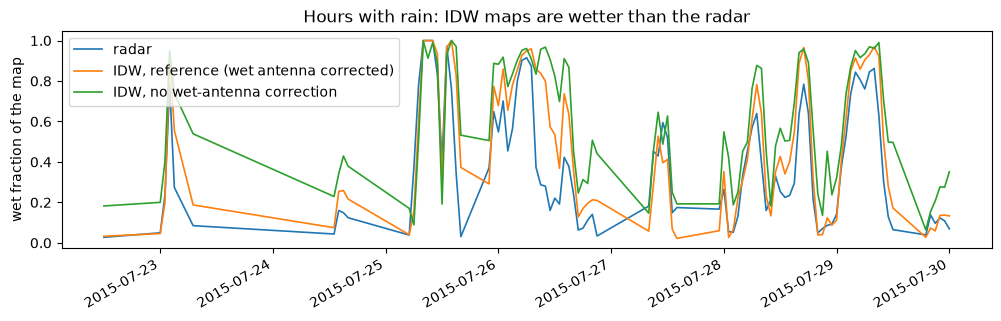

IDW, reference (wet antenna corrected)    1.23
IDW, no wet-antenna correction            1.56
Name: mean wet fraction / radar's, dtype: float64


In [4]:
IDW = dict(power=2.0, radius_m=10_000.0)
idw = {k: idw_map(v, grid, **IDW) for k, v in links.items()}
war = pd.DataFrame({"radar": (radar >= WET).where(radar.notnull()).mean(("lat", "lon")).to_series(),
                    **{f"IDW, {k}": (m >= WET).where(m.notnull()).mean(("lat", "lon")).to_series()
                       for k, m in idw.items()}}).loc[wet_hours.values]
ax = war.plot(figsize=(12, 3.2), lw=1.2)
ax.set_ylabel("wet fraction of the map"); ax.set_xlabel(""); ax.set_title("Hours with rain: IDW maps are wetter than the radar")
plt.show()
print((war.drop(columns="radar").mean() / war.radar.mean()).round(2).rename("mean wet fraction / radar's"))

The fix used in geostatistics is to interpolate the **indicator** of rain first. With
$I_i = 1$ if link $i$ is wet ($r_i \ge 0.1$ mm) and 0 otherwise, the same IDW weights give

$$p(\mathbf{x}) = \frac{\sum_i w_i\, I_i}{\sum_i w_i},$$

the distance-weighted share of nearby links that saw rain: a wet probability. (Indicator
kriging, Journel 1983, does the same with kriging weights.) By hand, then with FieldSense:

In [5]:
def idw_by_hand(values, lat, lon, power=2.0, radius_m=10_000.0):
    sx, sy = to_local_xy(lat, lon, lat0, lon0)
    d = np.hypot(dst[:, None, 0] - sx[None, :], dst[:, None, 1] - sy[None, :])
    with np.errstate(divide="ignore"):
        W = 1.0 / d ** power
    W[d > radius_m] = 0.0
    ok = np.isfinite(values)
    num, den = W @ np.where(ok, values, 0.0), W @ ok
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, num / den, np.nan).T.reshape((-1,) + grid.shape)


v = links["no wet-antenna correction"]
ind = np.where(v.values >= WET, 1.0, 0.0)
ind[np.isnan(v.values)] = np.nan
p_hand = idw_by_hand(ind, v.mid_lat.values, v.mid_lon.values)
p_core = wa.wet_probability(v, grid, WET, **IDW)
print("hand-written vs core.maps.wet_area.wet_probability, max difference:",
      float(np.nanmax(np.abs(p_hand - p_core.values))))

hand-written vs core.maps.wet_area.wet_probability, max difference: 2.9801295542419837e-08


## 4. A wet mask, and IDW of the wet links only

Two maps follow from $p$:

* **masked IDW**: the plain IDW map, set to 0 where $p < p_{\text{cut}}$ (here 0.5: most nearby
  links are dry);
* **conditional IDW**: IDW of the *wet* links only - the rain where it rains, not diluted
  by the dry links - with the same mask. Where a cell is judged wet but no wet link is in
  range, it keeps the plain IDW value.

Below, the hour where the mask changes the map most.

masked IDW by hand vs core, max difference: 0.0


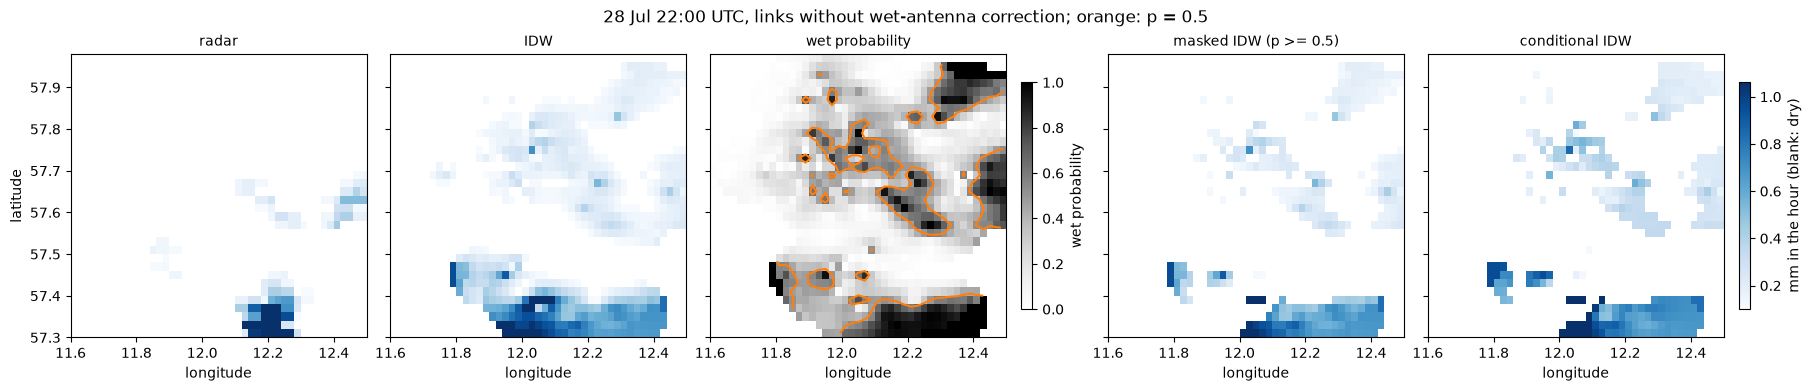

In [6]:
m_hand = np.where((p_hand >= 0.5) | np.isnan(idw["no wet-antenna correction"].values), idw["no wet-antenna correction"].values, 0.0)
masked = {k: wa.masked_idw(v, grid, WET, 0.5, **IDW) for k, v in links.items()}
cond = {k: wa.conditional_idw(v, grid, WET, 0.5, **IDW) for k, v in links.items()}
print("masked IDW by hand vs core, max difference:",
      float(np.nanmax(np.abs(m_hand - masked["no wet-antenna correction"].values))))

k = "no wet-antenna correction"
dried = ((idw[k] >= WET) & (masked[k] < WET)).mean(("lat", "lon"))
t = dried.idxmax("time").values
panels = {"radar": radar, "IDW": idw[k], "wet probability": p_core, "masked IDW (p >= 0.5)": masked[k],
          "conditional IDW": cond[k]}
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), sharey=True, constrained_layout=True)
vmax = float(np.nanquantile(radar.sel(time=t), 0.99)) or 1.0
for ax, (name, m) in zip(axes, panels.items()):
    f = m.sel(time=t)
    if name == "wet probability":
        im2 = ax.pcolormesh(grid.lon, grid.lat, f, vmin=0, vmax=1, cmap="Greys")
        ax.contour(grid.lon, grid.lat, f, levels=[0.5], colors="C1")
    else:
        im = ax.pcolormesh(grid.lon, grid.lat, f.where(f >= WET), vmin=WET, vmax=vmax, cmap="Blues")
    ax.set_title(name, fontsize=10); ax.set_xlabel("longitude")
axes[0].set_ylabel("latitude")
fig.colorbar(im2, ax=axes[2], label="wet probability", shrink=0.8)
fig.colorbar(im, ax=axes[-1], label="mm in the hour (blank: dry)", shrink=0.8)
fig.suptitle(f"{pd.Timestamp(t):%d %b %H:%M} UTC, links without wet-antenna correction; orange: p = 0.5")
plt.show()

## 5. Scoring where it rains

Over all hours with rain, against the radar on the grid and at the held-out gauges, with
`core.maps.scores.scores` (NRMSE, correlation, CSI, FAR at 0.1 mm) and
`core.maps.wet_area.wet_area_scores`: the **wet-area ratio** (the map's wet fraction over the
reference's, 1 is right) and the **peak ratio** (99th percentile over the reference's).

In [7]:
def score(est, ref):
    s = scores(est.values, ref.values, wet_threshold=WET)
    return {**{k: s[k] for k in ("nrmse", "corr", "csi", "far")}, **wa.wet_area_scores(est.values, ref.values, WET)}


rows = []
for k in links:
    for name, m in (("IDW", idw[k]), ("masked IDW", masked[k]), ("conditional IDW", cond[k])):
        m = m.sel(time=wet_hours)
        rows.append({"retrieval": k, "map": name, "reference": "radar", **score(m, radar.sel(time=wet_hours))})
        rows.append({"retrieval": k, "map": name, "reference": "gauges",
                     **score(at_gauges(m), gauges.sel(time=wet_hours).transpose("station", "time"))})
table5 = pd.DataFrame(rows).set_index(["reference", "retrieval", "map"]).round(3)
table5[["war_ratio", "far", "csi", "nrmse", "corr", "peak_ratio"]]

,,,war_ratio,far,csi,nrmse,corr,peak_ratio
reference,retrieval,map,,,,,,
radar,reference (wet antenna corrected),IDW,1.219,0.275,0.662,2.038,0.629,0.897
gauges,reference (wet antenna corrected),IDW,1.111,0.184,0.752,1.517,0.856,0.876
radar,reference (wet antenna corrected),masked IDW,1.070,0.223,0.671,2.047,0.628,0.897
gauges,reference (wet antenna corrected),masked IDW,1.012,0.149,0.749,1.518,0.855,0.876
radar,reference (wet antenna corrected),conditional IDW,1.081,0.229,0.668,2.058,0.628,0.908
gauges,reference (wet antenna corrected),conditional IDW,1.022,0.155,0.746,1.514,0.856,0.877
radar,no wet-antenna correction,IDW,1.539,0.402,0.569,2.783,0.561,1.336
gauges,no wet-antenna correction,IDW,1.553,0.388,0.593,3.700,0.822,1.756
radar,no wet-antenna correction,masked IDW,1.283,0.328,0.607,2.785,0.562,1.336


For the corrected retrieval the mask brings the wet area to within a few percent of the
gauges' and 7% of the radar's (from 11% and 22% too wet) and lowers the false alarms. For the
uncorrected one it helps only partly (1.55 to 1.29): there the links *themselves* report rain
when it is dry - the wet antenna again - and the indicator inherits it. The amounts (NRMSE,
correlation) barely move in either case, because the hourly error sits where the heavy rain
is, not in the drizzle at the edges. Conditional IDW does not bring back the peaks either:
they fall *between* links, which no interpolation of the same links can recover. On three
networks and 16 simulated cases [`maps/wet_area`](../projects/maps/wet_area/) finds the same.

## 6. A link's error depends on its length

The fairest check of a link is against the radar **averaged along its path** (tutorial 4):
no interpolation is involved. Points every 250 m along the path, the radar cell under each,
averaged - by hand for one link, then for all with `core.maps.geometry.path_average_points`.

In [8]:
table = pd.DataFrame({c: lk[c].values for c in ("site_0_lat", "site_0_lon", "site_1_lat", "site_1_lon")},
                     index=pd.Index(lk.link.values, name="link"))
rad_path = path_average_points(radar, table).transpose("link", "time")

r = table.iloc[0]
n = max(3, int(np.ceil(float(lk.length[0]) * 1000 / 250)) + 1)
s = np.linspace(0, 1, n)
pts = radar.sel(lat=xr.DataArray(r.site_0_lat + s * (r.site_1_lat - r.site_0_lat), dims="s"),
                lon=xr.DataArray(r.site_0_lon + s * (r.site_1_lon - r.site_0_lon), dims="s"), method="nearest")
print("link", table.index[0], f"({float(lk.length[0]):.2f} km): by hand vs core, max difference",
      float(np.nanmax(np.abs(pts.mean("s").values - rad_path.isel(link=0).values))))

BINS = [0, 1, 2, 4, 8, 100]
LABELS = ["0-1 km", "1-2 km", "2-4 km", "4-8 km", "> 8 km"]


def by_length(v, hours):
    rp = rad_path.sel(link=v.link, time=hours)
    df = pd.DataFrame({"link": v.sel(time=hours).values.ravel(), "radar": rp.values.ravel(),
                       "bin": np.repeat(pd.cut(v.length.values, BINS, labels=LABELS, right=False), len(hours))})
    df = df.dropna()
    df = df[(df.link >= WET) | (df.radar >= WET)]
    return df.groupby("bin", observed=True).apply(lambda d: pd.Series({
        "links x hours": len(d), "rel_bias": d.link.sum() / d.radar.sum() - 1,
        "mse": np.mean((d.link - d.radar) ** 2)}), include_groups=False)


err = {k: by_length(v, lk.time.values) for k, v in links.items()}
pd.concat(err, axis=1).round(3)

link 10001 (0.69 km): by hand vs core, max difference 0.0


reference (wet antenna corrected)                  \
                           links x hours rel_bias    mse   
bin                                                        
0-1 km                            3333.0    0.552  6.406   
1-2 km                            4927.0    0.239  1.826   
2-4 km                            5619.0    0.105  1.467   
4-8 km                            3241.0    0.053  1.089   
> 8 km                             714.0   -0.027  0.650   

       no wet-antenna correction                   
                   links x hours rel_bias     mse  
bin                                                
0-1 km                    3989.0    3.251  12.370  
1-2 km                    7285.0    1.418   4.740  
2-4 km                    7101.0    0.558   2.440  
4-8 km                    4241.0    0.394   1.523  
> 8 km                    1203.0    0.800   1.257

Without a wet-antenna correction the shortest links read far too high: the antenna's few
tenths of a dB, divided by a short path, become a large specific attenuation. The published
reference retrieval corrects most of it; the remaining spread is the error the map
inherits.

## 7. Links weighted by the inverse of their error variance

If each link's error variance $\sigma_i^2$ is known, the natural IDW weight is
$w_i = d_i^{-p} / \sigma_i^2$: a noisy link counts less than a reliable one at the same
distance. Here $\sigma^2$ per length bin is the mean squared error above, **learned on the
first four days** and used on the last four, so the scores are out of sample.
`idw_map(..., weights=)` multiplies each link's IDW weight by its own factor.

In [9]:
hours = lk.time.values
train, test = hours[hours < np.datetime64("2015-07-26")], hours[hours >= np.datetime64("2015-07-26")]
test_wet = np.intersect1d(test, wet_hours.values)

rows = []
for k, v in links.items():
    mse = by_length(v, train)["mse"]
    sig2 = mse.reindex(pd.cut(v.length.values, BINS, labels=LABELS, right=False)).to_numpy(float)
    w = 1.0 / np.where(np.isfinite(sig2), sig2, np.nanmax(mse))
    maps = {"IDW": idw[k], "IDW weighted by 1/sigma^2": idw_map(v, grid, weights=w / w.mean(), **IDW),
            "IDW without links < 1 km": idw_map(v.isel(link=np.flatnonzero(v.length.values >= 1)), grid, **IDW)}
    for name, m in maps.items():
        m = m.sel(time=test_wet)
        rows.append({"retrieval": k, "map": name,
                     **{f"radar {q}": x for q, x in score(m, radar.sel(time=test_wet)).items() if q in ("nrmse", "corr")},
                     **{f"gauges {q}": x for q, x in score(at_gauges(m), gauges.sel(time=test_wet).transpose("station", "time")).items()
                        if q in ("nrmse", "corr")}})
pd.DataFrame(rows).set_index(["retrieval", "map"]).round(3)

radar nrmse  \
retrieval                         map                                      
reference (wet antenna corrected) IDW                              2.084   
                                  IDW weighted by 1/sigma^2        2.066   
                                  IDW without links < 1 km         2.077   
no wet-antenna correction         IDW                              3.036   
                                  IDW weighted by 1/sigma^2        2.897   
                                  IDW without links < 1 km         2.884   

                                                             radar corr  \
retrieval                         map                                     
reference (wet antenna corrected) IDW                             0.672   
                                  IDW weighted by 1/sigma^2       0.675   
                                  IDW without links < 1 km        0.673   
no wet-antenna correction         IDW                             0.625   
                                  IDW weighted by 1/sigma^2       0.630   
                                  IDW without links < 1 km        0.631   

                                                             gauges nrmse  \
retrieval                         map                                       
reference (wet antenna corrected) IDW                               1.643   
                                  IDW weighted by 1/sigma^2         1.617   
                                  IDW without links < 1 km          1.633   
no wet-antenna correction         IDW                               3.879   
                                  IDW weighted by 1/sigma^2         3.160   
                                  IDW without links < 1 km          2.380   

                                                             gauges corr  
retrieval                         map                                     
reference (wet antenna corrected) IDW                              0.854  
                                  IDW weighted by 1/sigma^2        0.863  
                                  IDW without links < 1 km         0.861  
no wet-antenna correction         IDW                              0.817  
                                  IDW weighted by 1/sigma^2        0.834  
                                  IDW without links < 1 km         0.865

For links without a wet-antenna correction the weights cut the error at the gauges (NRMSE
3.88 to 3.16); on this small subset, simply dropping the links under 1 km does even better
(2.38), because nearly all of the damage is in that one bin. For the corrected reference
retrieval there is little left to repair. On three networks
[`maps/link_weights`](../projects/maps/link_weights/) finds the same pattern: the
power-law map's NRMSE at held-out gauges falls from 3.62 to 2.33 in Gothenburg and from
1.56 to 0.95 in New York, while the RNN retrieval, whose error is flat with length, gains
nothing.

## Summary

* Interpolating amounts makes maps wet everywhere. Interpolating the wet **indicator** first
  gives a wet probability, and a mask at $p = 0.5$ puts the wet area right and cuts false
  alarms - but it does not fix amounts or peaks, which are lost between links.
* A link's error depends on its length because the wet-antenna offset does not scale with the
  path. Learned per length bin on some storms and used as inverse-variance weights on
  others, it makes power-law link maps much better; a retrieval that already handles the wet
  antenna gains little.
* Both corrections use only the links themselves: no radar or gauge is needed to apply them,
  only to learn the error model.

Next: the proposed projects in [`docs/pre_projects`](../docs/pre_projects/README.md) take
both further - a learned path law and a wet antenna with memory
([`physics_ml/path_law_1d`](../projects/physics_ml/path_law_1d/)), and learned 2-D maps
([`maps/learned_2d`](../projects/maps/)).

## References and links

* Andersson, J. C. M., et al. (2022): OpenMRG: Open data from Microwave links, Radar, and
  Gauges for rainfall quantification in Gothenburg, Sweden. *Earth Syst. Sci. Data*, 14,
  5411-5426, [doi:10.5194/essd-14-5411-2022](https://doi.org/10.5194/essd-14-5411-2022).
* Journel, A. G. (1983): Nonparametric estimation of spatial distributions. *Math. Geol.*,
  15(3), 445-468, [doi:10.1007/BF01031292](https://doi.org/10.1007/BF01031292).
* Schleiss, M., Rieckermann, J. and Berne, A. (2013): Quantification and modeling of
  wet-antenna attenuation for commercial microwave links. *IEEE Geosci. Remote Sens. Lett.*,
  10(5), 1195-1199, [doi:10.1109/LGRS.2012.2236074](https://doi.org/10.1109/LGRS.2012.2236074).
* Leijnse, H., Uijlenhoet, R. and Stricker, J. N. M. (2008): Microwave link rainfall
  estimation: effects of link length and frequency, temporal sampling, power resolution, and
  wet antenna attenuation. *Adv. Water Resour.*, 31(11), 1481-1493,
  [doi:10.1016/j.advwatres.2008.03.004](https://doi.org/10.1016/j.advwatres.2008.03.004).
* Pastorek, J., et al. (2022): Precipitation estimates from commercial microwave links:
  practical approaches to wet-antenna correction. *IEEE Trans. Geosci. Remote Sens.*, 60,
  [doi:10.1109/TGRS.2021.3110004](https://doi.org/10.1109/TGRS.2021.3110004).
* Berne, A. and Uijlenhoet, R. (2007): Path-averaged rainfall estimation using microwave
  links: uncertainty due to spatial rainfall variability. *Geophys. Res. Lett.*, 34, L07403,
  [doi:10.1029/2007GL029409](https://doi.org/10.1029/2007GL029409).